# Additional Datasets Notebook

Blank starter notebook for:
- `education_records.csv`
- `health_wellbeing_records.csv`
- `home_visitations.csv`
- `intervention_plans.csv`
- `incident_reports.csv`

In [22]:
import pandas as pd
from pathlib import Path

# Update this path if your CSV files are in a different folder.
data_dir = Path(".")

datasets = {
    "education_records": "education_records.csv",
    "health_wellbeing_records": "health_wellbeing_records.csv",
    "home_visitations": "home_visitations.csv",
    "intervention_plans": "intervention_plans.csv",
    "incident_reports": "incident_reports.csv",
}

# dataframes = {name: pd.read_csv(data_dir / filename) for name, filename in datasets.items()}
# dataframes["education_records"].head()

In [23]:
# Chapter 1: Setup and Load Data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")

# Make Chapter 1 self-contained and robust to different notebook working directories.
datasets = {
    "education_records": "education_records.csv",
    "health_wellbeing_records": "health_wellbeing_records.csv",
    "home_visitations": "home_visitations.csv",
    "intervention_plans": "intervention_plans.csv",
    "incident_reports": "incident_reports.csv",
}

candidate_dirs = [
    Path("."),
    Path("datasets"),
    Path("../datasets"),
    Path("../../datasets"),
]

resolved_data_dir = None
for d in candidate_dirs:
    if all((d / fname).exists() for fname in datasets.values()):
        resolved_data_dir = d
        break

if resolved_data_dir is None:
    missing_report = {
        str(d): [fname for fname in datasets.values() if not (d / fname).exists()]
        for d in candidate_dirs
    }
    raise FileNotFoundError(
        "Could not find all dataset CSVs. Checked: "
        + ", ".join(str(d) for d in candidate_dirs)
        + f"\nMissing by location: {missing_report}"
    )

dataframes = {
    name: pd.read_csv(resolved_data_dir / filename)
    for name, filename in datasets.items()
}

print(f"Using data directory: {resolved_data_dir.resolve()}")
print("Loaded datasets:", list(dataframes.keys()))
for name, df in dataframes.items():
    print(f"{name}: {df.shape}")

Using data directory: C:\Users\abiga\IntextW2026\datasets
Loaded datasets: ['education_records', 'health_wellbeing_records', 'home_visitations', 'intervention_plans', 'incident_reports']
education_records: (534, 10)
health_wellbeing_records: (534, 14)
home_visitations: (1337, 14)
intervention_plans: (180, 11)
incident_reports: (100, 12)


In [24]:
# Chapter 2: First Look (Schema and Sample Rows)
for name, df in dataframes.items():
    print("=" * 80)
    print(f"Dataset: {name}")
    display(df.head())
    display(df.info())
    display(df.describe(include="all").T.head(20))

Dataset: education_records


,education_record_id,resident_id,record_date,education_level,school_name,enrollment_status,attendance_rate,progress_percent,completion_status,notes
0,1,1,2023-10-01,Vocational,School 8,Enrolled,0.966,37.7,NotStarted,Progress: NotStarted
1,2,1,2023-11-01,Secondary,School 20,Enrolled,0.693,33.0,InProgress,Progress: InProgress
2,3,1,2023-12-01,Vocational,School 18,Enrolled,0.744,54.0,InProgress,Progress: InProgress
3,4,1,2024-01-01,Primary,School 2,Enrolled,0.681,51.2,InProgress,Progress: InProgress
4,5,1,2024-02-01,Vocational,School 3,Enrolled,0.721,44.2,InProgress,Progress: InProgress


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   education_record_id  534 non-null    int64  
 1   resident_id          534 non-null    int64  
 2   record_date          534 non-null    object 
 3   education_level      534 non-null    object 
 4   school_name          534 non-null    object 
 5   enrollment_status    534 non-null    object 
 6   attendance_rate      534 non-null    float64
 7   progress_percent     534 non-null    float64
 8   completion_status    534 non-null    object 
 9   notes                534 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 41.8+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
education_record_id,534.0,NaN,NaN,NaN,267.5,154.296792,1.0,134.25,267.5,400.75,534.0
resident_id,534.0,NaN,NaN,NaN,30.29588,17.191846,1.0,15.0,30.0,45.0,60.0
record_date,534,38,2024-05-01,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,534,4,Secondary,207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
school_name,534,20,School 3,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enrollment_status,534,1,Enrolled,534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attendance_rate,534.0,NaN,NaN,NaN,0.736109,0.123185,0.384,0.65,0.737,0.82475,1.0
progress_percent,534.0,NaN,NaN,NaN,78.53764,23.668177,0.0,59.9,85.4,100.0,100.0
completion_status,534,3,InProgress,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
notes,534,3,Progress: InProgress,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN


...

Dataset: incident_reports


,incident_id,resident_id,safehouse_id,incident_date,incident_type,severity,description,response_taken,resolved,resolution_date,reported_by,follow_up_required
0,1,1,4,2024-06-22,Medical,Medium,Medical incident reported on 2024-06-22,Response to medical,True,2024-07-01,SW-19,False
1,2,1,4,2026-02-10,Security,High,Security incident reported on 2026-02-10,Response to security,False,NaN,SW-20,True
2,3,1,4,2024-02-03,RunawayAttempt,Low,RunawayAttempt incident reported on 2024-02-03,Response to runawayattempt,True,2024-02-10,SW-18,False
3,4,1,4,2025-04-17,Behavioral,Low,Behavioral incident reported on 2025-04-17,Response to behavioral,True,2025-04-23,SW-12,False
4,5,3,1,2025-05-12,SelfHarm,High,SelfHarm incident reported on 2025-05-12,Response to selfharm,False,NaN,SW-08,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   incident_id         100 non-null    int64 
 1   resident_id         100 non-null    int64 
 2   safehouse_id        100 non-null    int64 
 3   incident_date       100 non-null    object
 4   incident_type       100 non-null    object
 5   severity            100 non-null    object
 6   description         100 non-null    object
 7   response_taken      100 non-null    object
 8   resolved            100 non-null    bool  
 9   resolution_date     71 non-null     object
 10  reported_by         100 non-null    object
 11  follow_up_required  100 non-null    bool  
dtypes: bool(2), int64(3), object(7)
memory usage: 8.1+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
incident_id,100.0,NaN,NaN,NaN,50.5,29.011492,1.0,25.75,50.5,75.25,100.0
resident_id,100.0,NaN,NaN,NaN,28.83,17.534413,1.0,14.0,26.0,44.0,59.0
safehouse_id,100.0,NaN,NaN,NaN,4.32,2.534131,1.0,2.0,4.0,6.0,9.0
incident_date,100,97,2025-03-21,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_type,100,7,RunawayAttempt,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
severity,100,3,Medium,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,100,100,Medical incident reported on 2024-06-22,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
response_taken,100,7,Response to runawayattempt,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolved,100,2,True,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolution_date,71,70,2024-08-06,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Chapter 3: Data Quality (Missing Values and Duplicates)
quality_summary = {}
for name, df in dataframes.items():
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    dup_count = df.duplicated().sum()

    quality_summary[name] = {
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": int(dup_count),
        "columns_with_missing": int((df.isna().sum() > 0).sum()),
    }

    print("=" * 80)
    print(f"Dataset: {name}")
    print(f"Duplicate rows: {dup_count}")
    display(missing.head(20).to_frame("missing_count"))

quality_df = pd.DataFrame(quality_summary).T
display(quality_df)

Dataset: education_records
Duplicate rows: 0


,missing_count


Dataset: health_wellbeing_records
Duplicate rows: 0


,missing_count


Dataset: home_visitations
Duplicate rows: 0


...

Dataset: intervention_plans
Duplicate rows: 0


,missing_count
case_conference_date,48


Dataset: incident_reports
Duplicate rows: 0


,missing_count
resolution_date,29


,rows,columns,duplicate_rows,columns_with_missing
education_records,534,10,0,0
health_wellbeing_records,534,14,0,0
home_visitations,1337,14,0,2
intervention_plans,180,11,0,1
incident_reports,100,12,0,1


Dataset: education_records | Numeric columns: 4


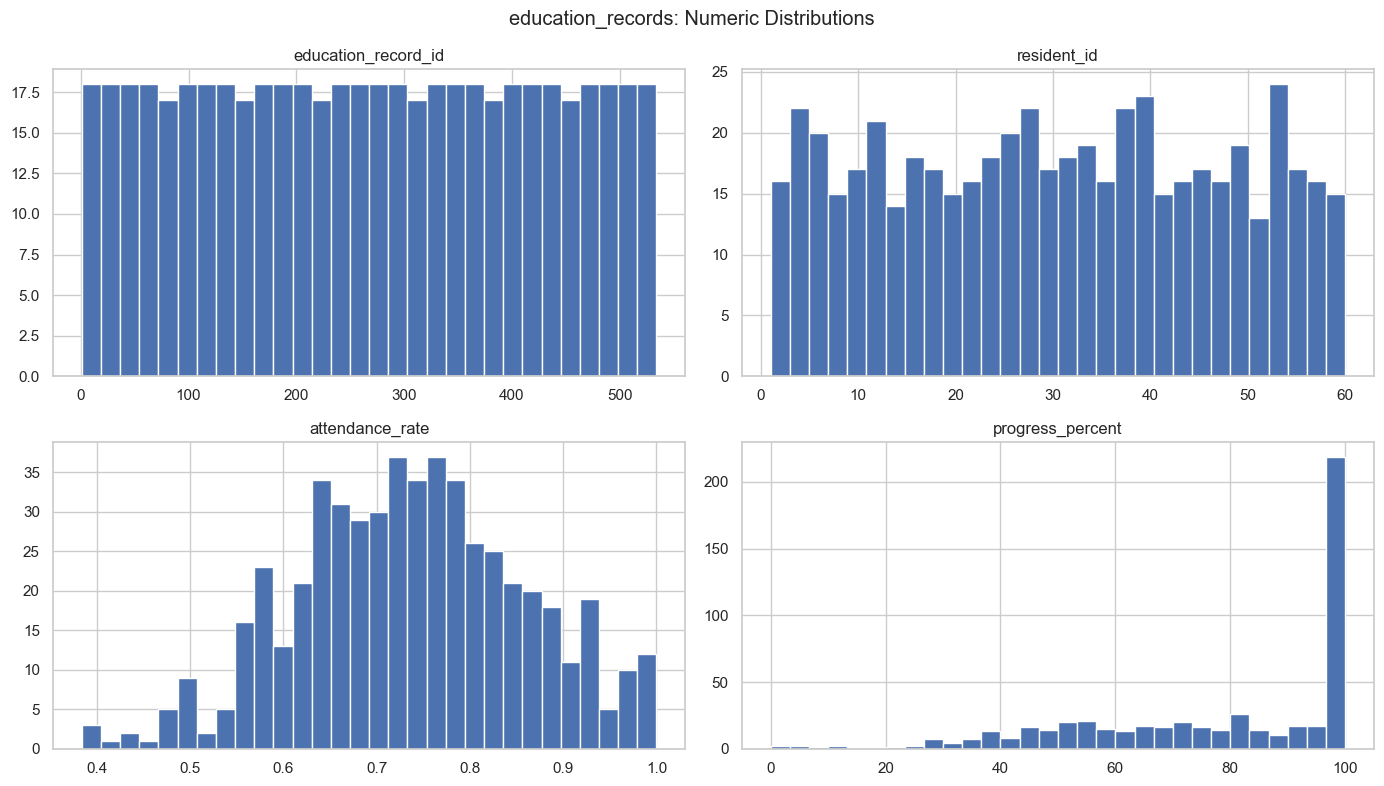

Dataset: health_wellbeing_records | Numeric columns: 9


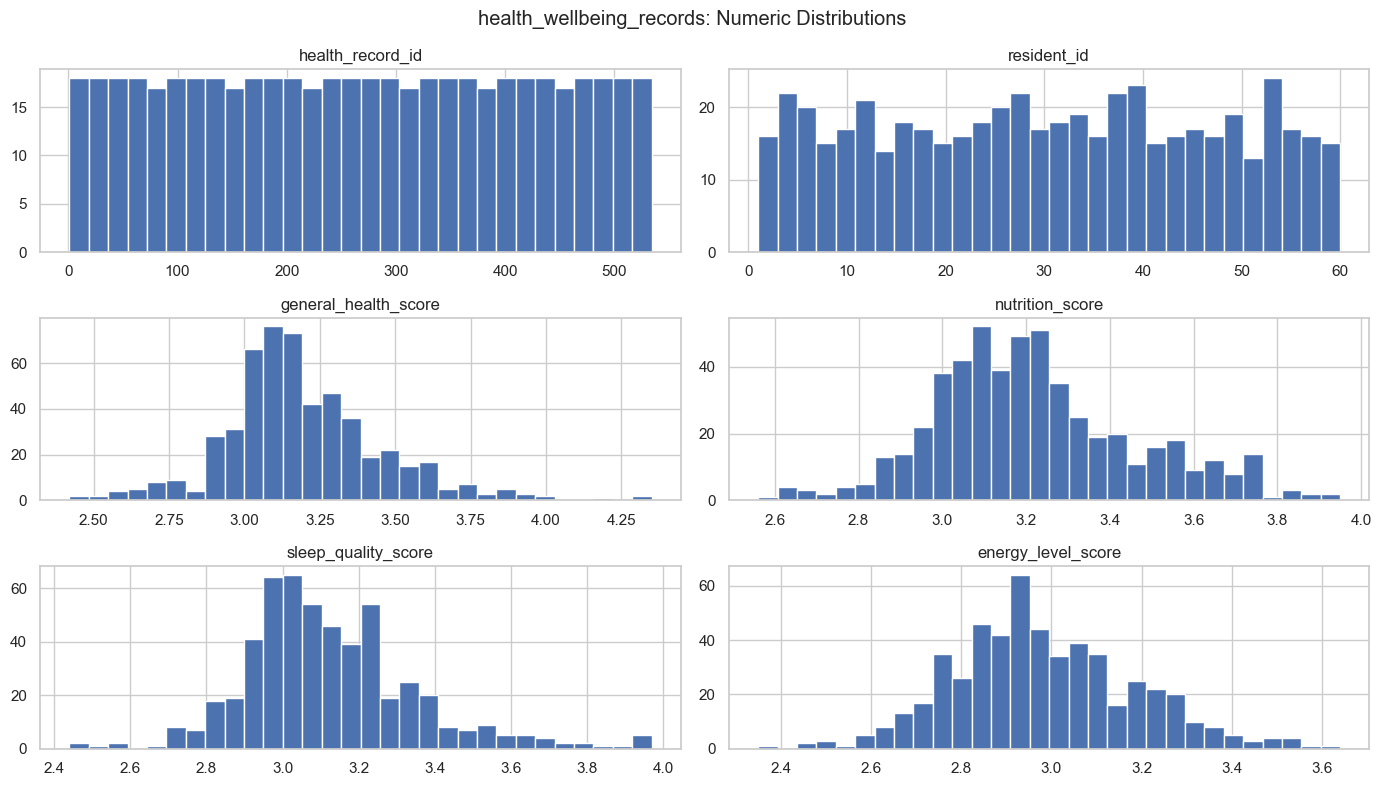

Dataset: home_visitations | Numeric columns: 2


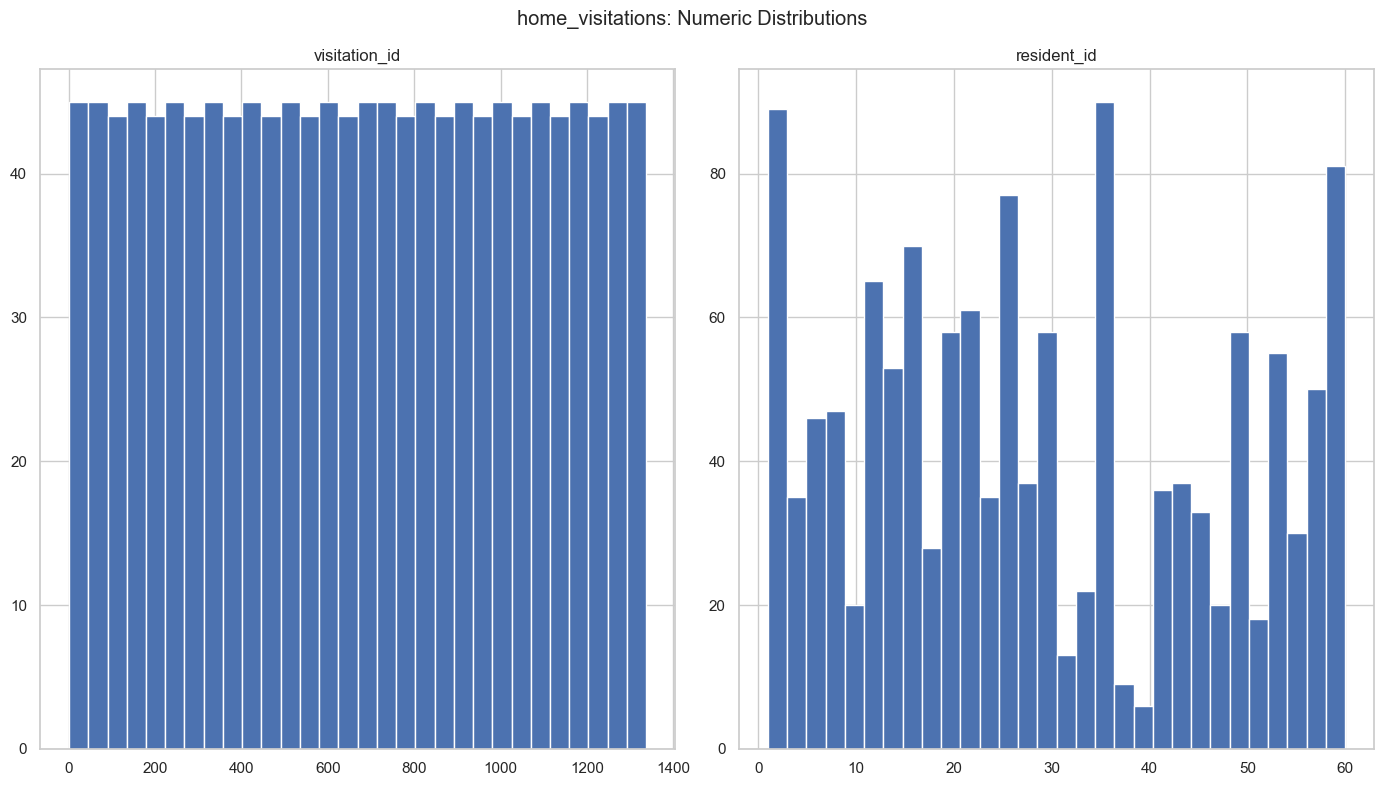

Dataset: intervention_plans | Numeric columns: 3


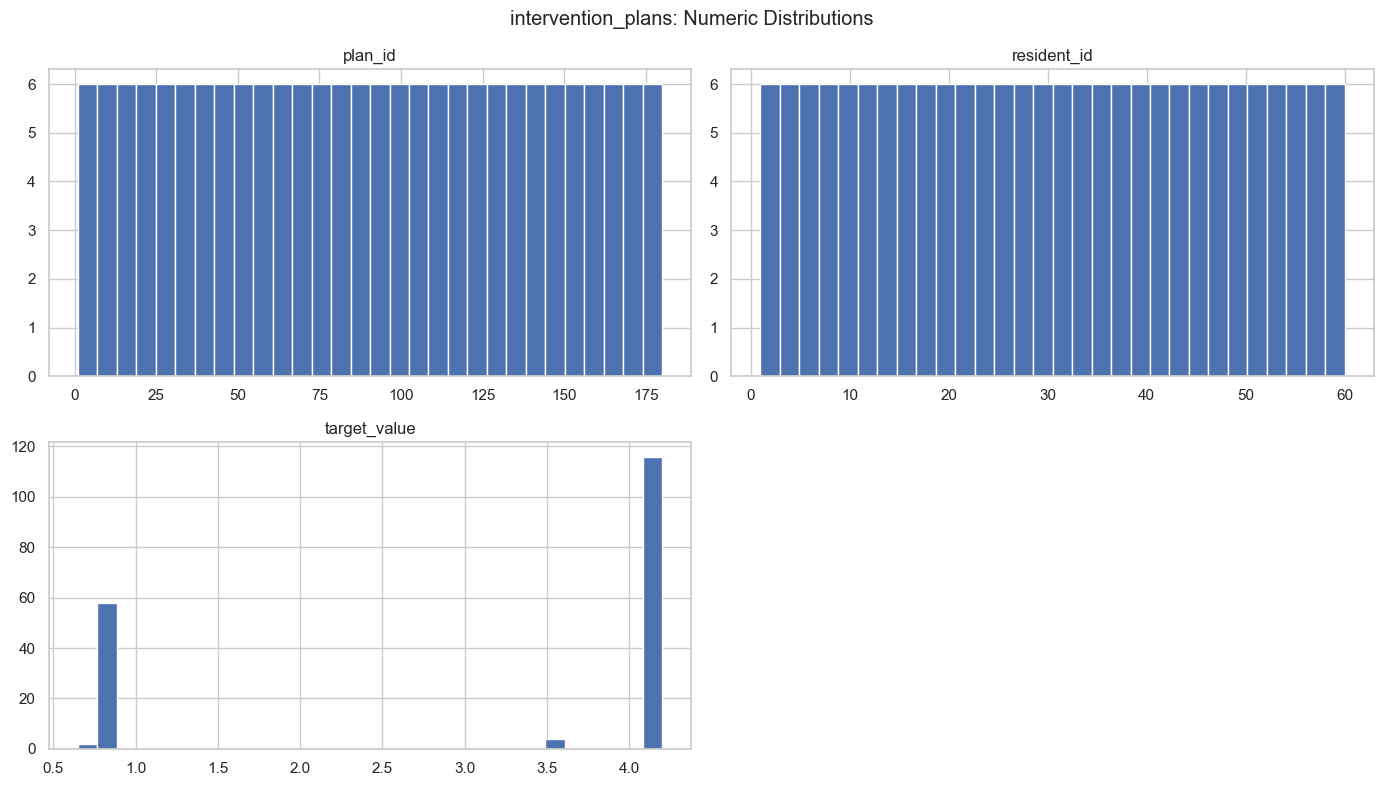

Dataset: incident_reports | Numeric columns: 3


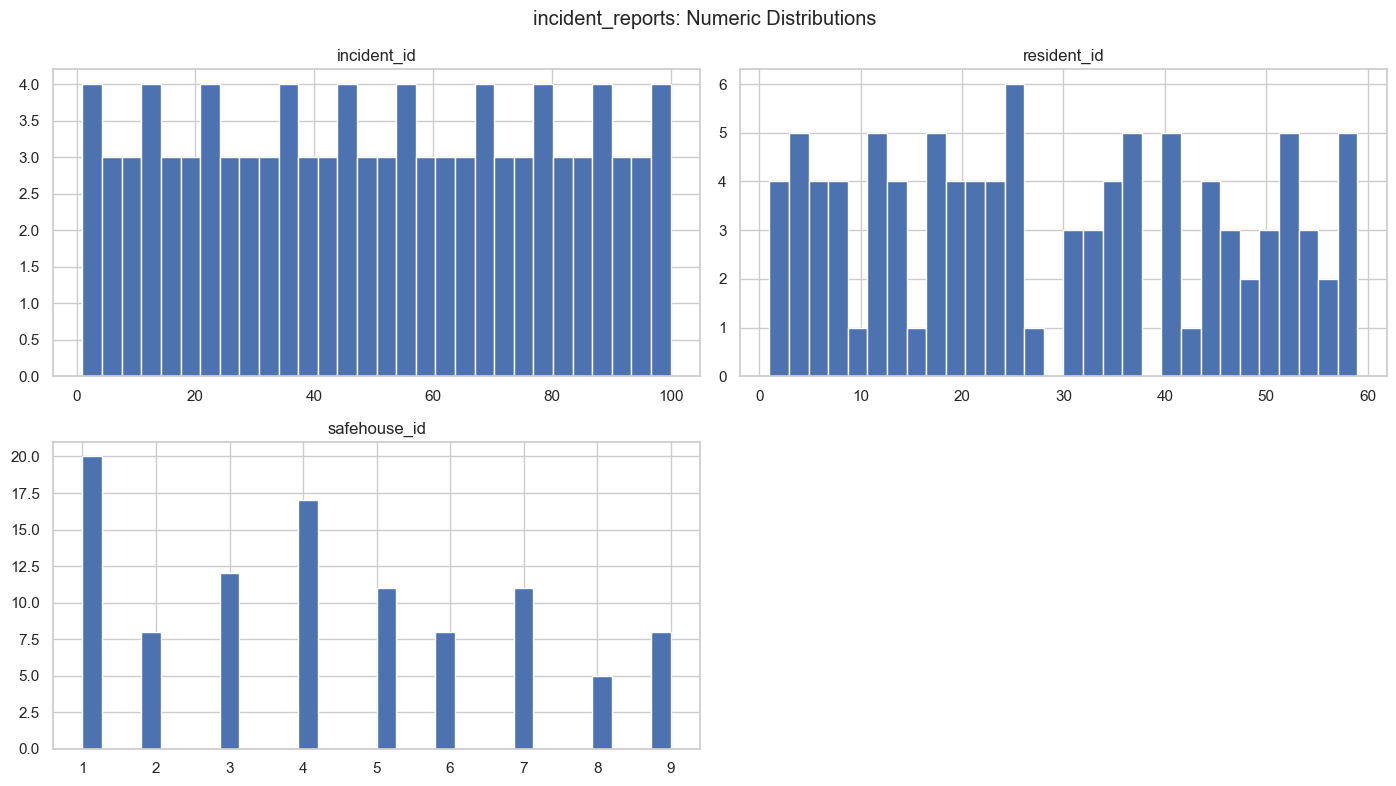

In [26]:
# Chapter 4: Univariate Analysis (Numeric Distributions)
for name, df in dataframes.items():
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    print("=" * 80)
    print(f"Dataset: {name} | Numeric columns: {len(numeric_cols)}")

    if not numeric_cols:
        print("No numeric columns found.")
        continue

    cols_to_plot = numeric_cols[:6]  # adjust as needed
    df[cols_to_plot].hist(figsize=(14, 8), bins=30)
    plt.suptitle(f"{name}: Numeric Distributions")
    plt.tight_layout()
    plt.show()

In [27]:
# Chapter 5: Categorical Analysis (Top Categories)
for name, df in dataframes.items():
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    print("=" * 80)
    print(f"Dataset: {name} | Categorical columns: {len(cat_cols)}")

    if not cat_cols:
        print("No categorical columns found.")
        continue

    for col in cat_cols[:5]:  # limit for readability
        print(f"\n{name} - {col}")
        display(df[col].value_counts(dropna=False).head(10).to_frame("count"))

Dataset: education_records | Categorical columns: 6

education_records - record_date


,count
record_date,
2024-05-01,23
2024-02-01,23
2023-10-01,21
2024-01-01,21
2024-03-01,21
2024-04-01,21
2023-12-01,20
2023-11-01,20
2024-06-01,19



education_records - education_level


,count
education_level,
Secondary,207
Primary,157
Vocational,111
CollegePrep,59



education_records - school_name


...

,count
severity,
Medium,48
Low,28
High,24



incident_reports - description


,count
description,
Medical incident reported on 2024-06-22,1
SelfHarm incident reported on 2025-11-11,1
Security incident reported on 2024-04-14,1
PropertyDamage incident reported on 2025-08-29,1
Behavioral incident reported on 2024-04-27,1
ConflictWithPeer incident reported on 2024-04-15,1
SelfHarm incident reported on 2024-11-09,1
RunawayAttempt incident reported on 2024-06-17,1
Behavioral incident reported on 2025-01-18,1



incident_reports - response_taken


,count
response_taken,
Response to runawayattempt,29
Response to behavioral,20
Response to security,16
Response to selfharm,14
Response to conflictwithpeer,11
Response to medical,6
Response to propertydamage,4


Dataset: education_records


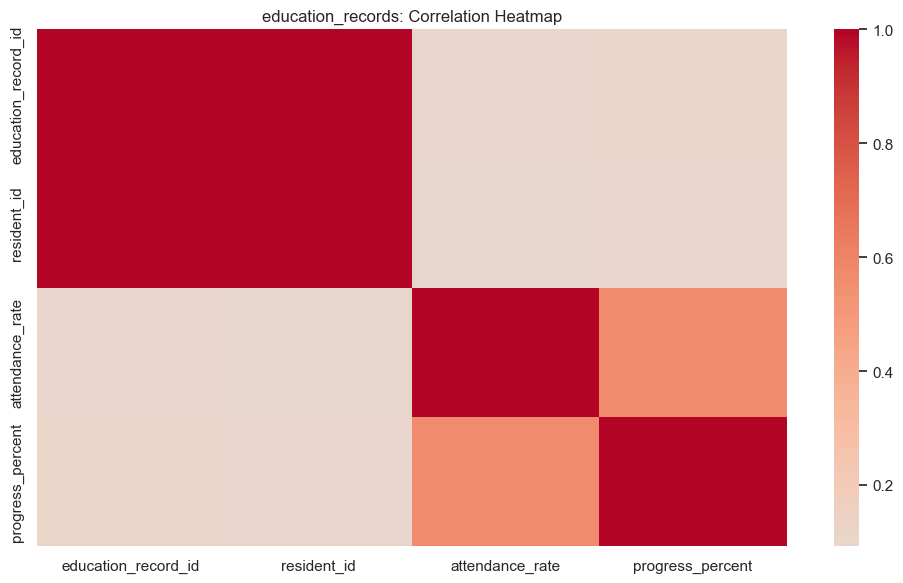

Dataset: health_wellbeing_records


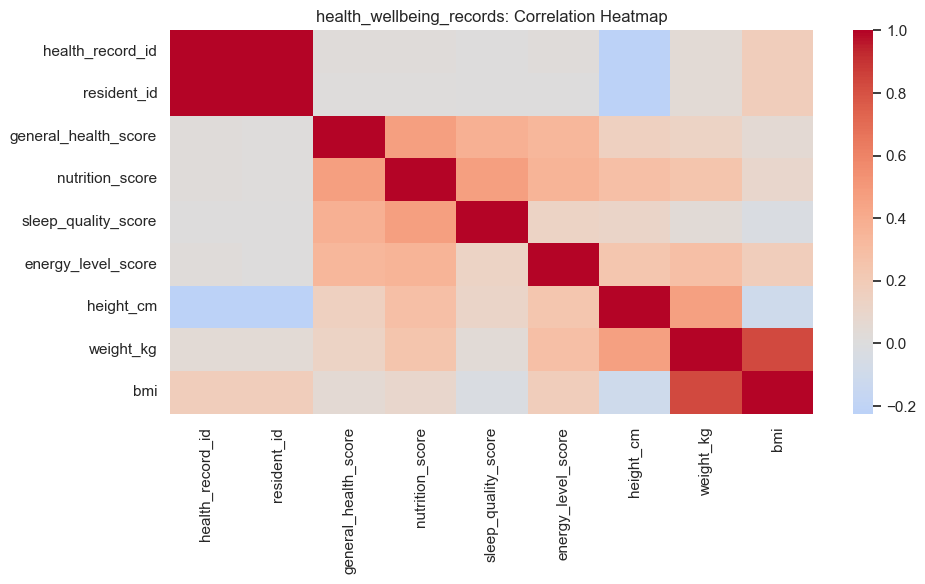

Dataset: home_visitations


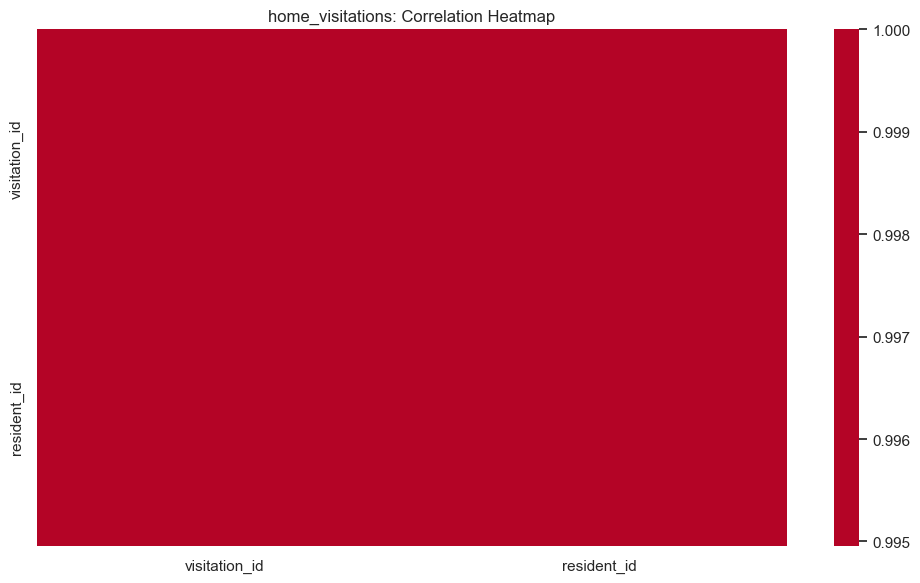

Dataset: intervention_plans


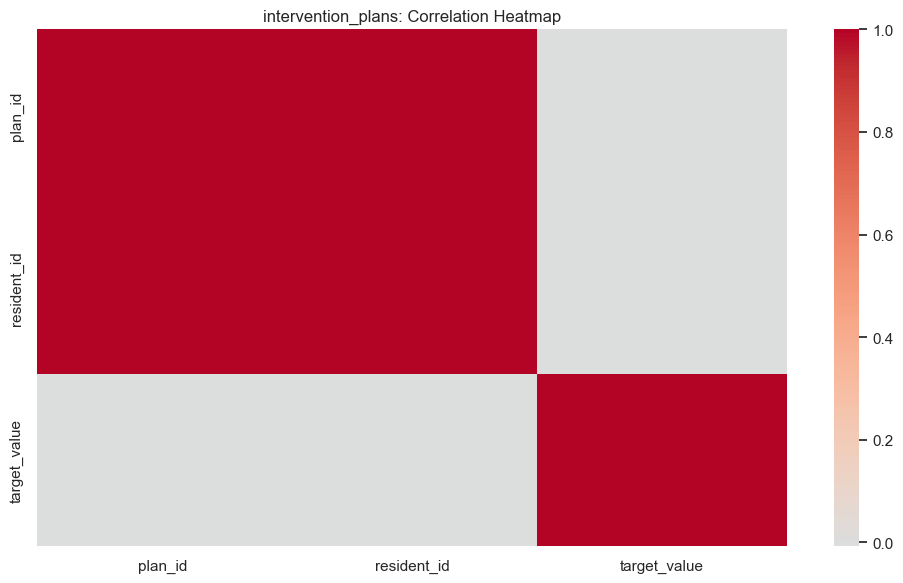

Dataset: incident_reports


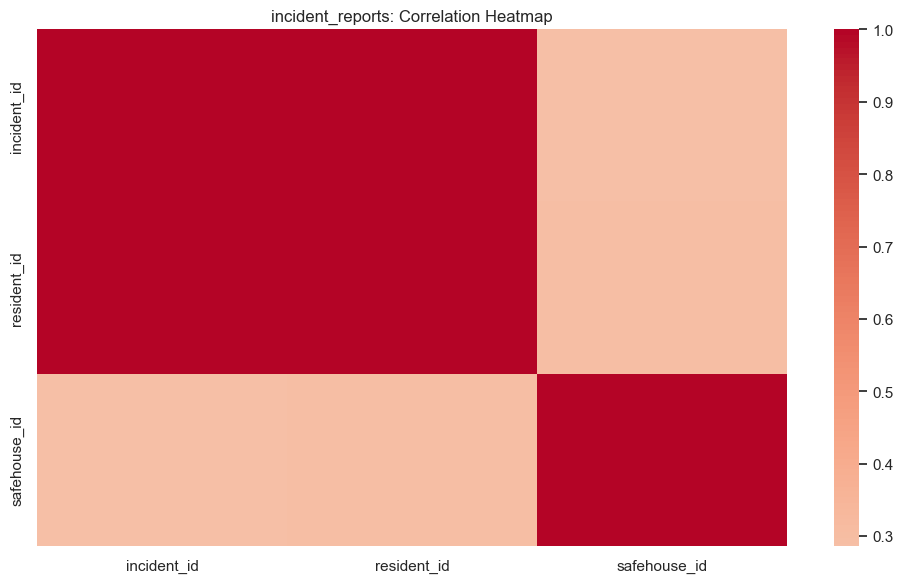

In [28]:
# Chapter 6: Bivariate Analysis and Correlation
for name, df in dataframes.items():
    numeric_df = df.select_dtypes(include=np.number)
    print("=" * 80)
    print(f"Dataset: {name}")

    if numeric_df.shape[1] < 2:
        print("Not enough numeric columns for correlation analysis.")
        continue

    corr = numeric_df.corr(numeric_only=True)
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title(f"{name}: Correlation Heatmap")
    plt.tight_layout()
    plt.show()

In [29]:
# Chapter 7: Outlier Detection (IQR Rule)
outlier_report = {}
for name, df in dataframes.items():
    numeric_cols = df.select_dtypes(include=np.number).columns
    report_rows = []

    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
        report_rows.append({"column": col, "outlier_count": int(outliers)})

    outlier_report[name] = pd.DataFrame(report_rows).sort_values("outlier_count", ascending=False)
    print("=" * 80)
    print(f"Dataset: {name}")
    display(outlier_report[name].head(10))

Dataset: education_records


,column,outlier_count
2,attendance_rate,1
0,education_record_id,0
1,resident_id,0
3,progress_percent,0


Dataset: health_wellbeing_records


,column,outlier_count
2,general_health_score,23
4,sleep_quality_score,22
8,bmi,10
3,nutrition_score,9
7,weight_kg,8
5,energy_level_score,7
6,height_cm,3
0,health_record_id,0
1,resident_id,0


Dataset: home_visitations


,column,outlier_count
0,visitation_id,0
1,resident_id,0


Dataset: intervention_plans


,column,outlier_count
0,plan_id,0
1,resident_id,0
2,target_value,0


Dataset: incident_reports


,column,outlier_count
0,incident_id,0
1,resident_id,0
2,safehouse_id,0


In [30]:
# Chapter 8: Key Insights and Next Steps
insights = {
    "data_quality_notes": "Add notes on missingness, duplicates, and potential data issues.",
    "important_features": "List top variables that stand out for each dataset.",
    "risk_or_anomaly_flags": "Record unusual patterns and possible causes.",
    "next_actions": "Define cleaning, feature engineering, and modeling priorities.",
}

for k, v in insights.items():
    print(f"- {k}: {v}")

# Optional: convert this into a markdown report or save summary tables to /artifacts.

- data_quality_notes: Add notes on missingness, duplicates, and potential data issues.
- important_features: List top variables that stand out for each dataset.
- risk_or_anomaly_flags: Record unusual patterns and possible causes.
- next_actions: Define cleaning, feature engineering, and modeling priorities.


Correlation analysis for: education_records


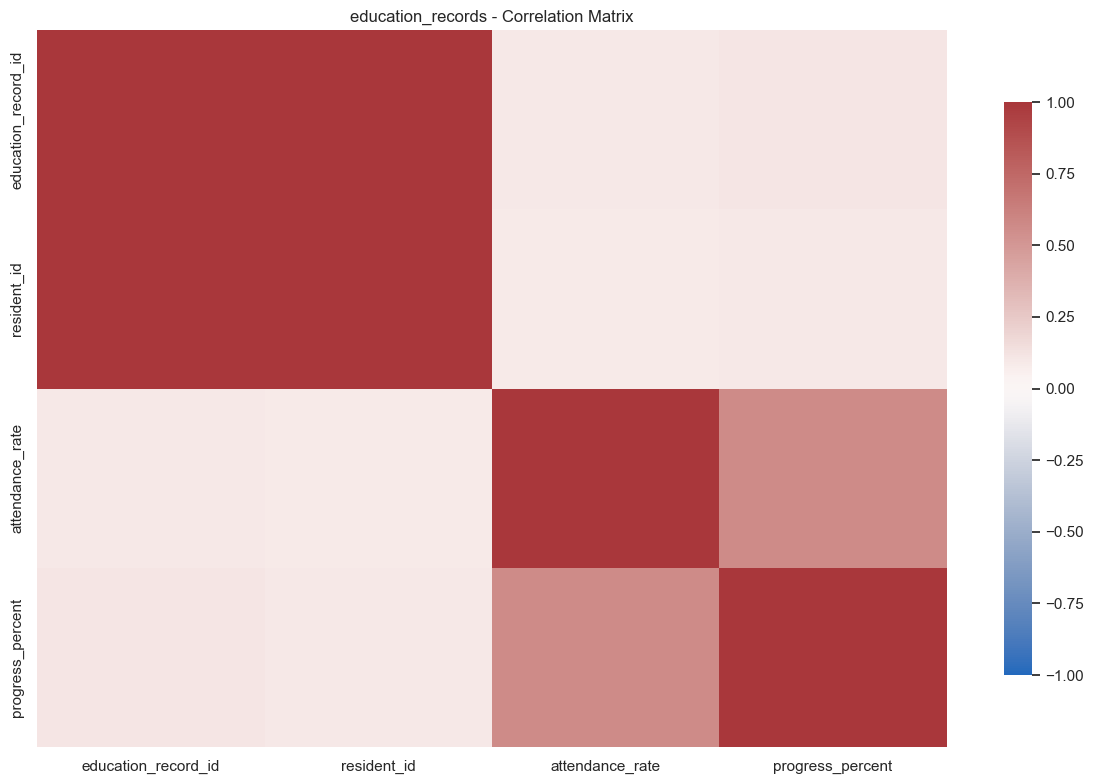

Top absolute correlations:


,feature_1,feature_2,correlation
0,education_record_id,resident_id,0.999685
3,resident_id,education_record_id,0.999685
8,attendance_rate,progress_percent,0.563803
11,progress_percent,attendance_rate,0.563803
2,education_record_id,progress_percent,0.109587
9,progress_percent,education_record_id,0.109587
5,resident_id,progress_percent,0.100844
10,progress_percent,resident_id,0.100844
1,education_record_id,attendance_rate,0.097980
6,attendance_rate,education_record_id,0.097980


Correlation analysis for: health_wellbeing_records


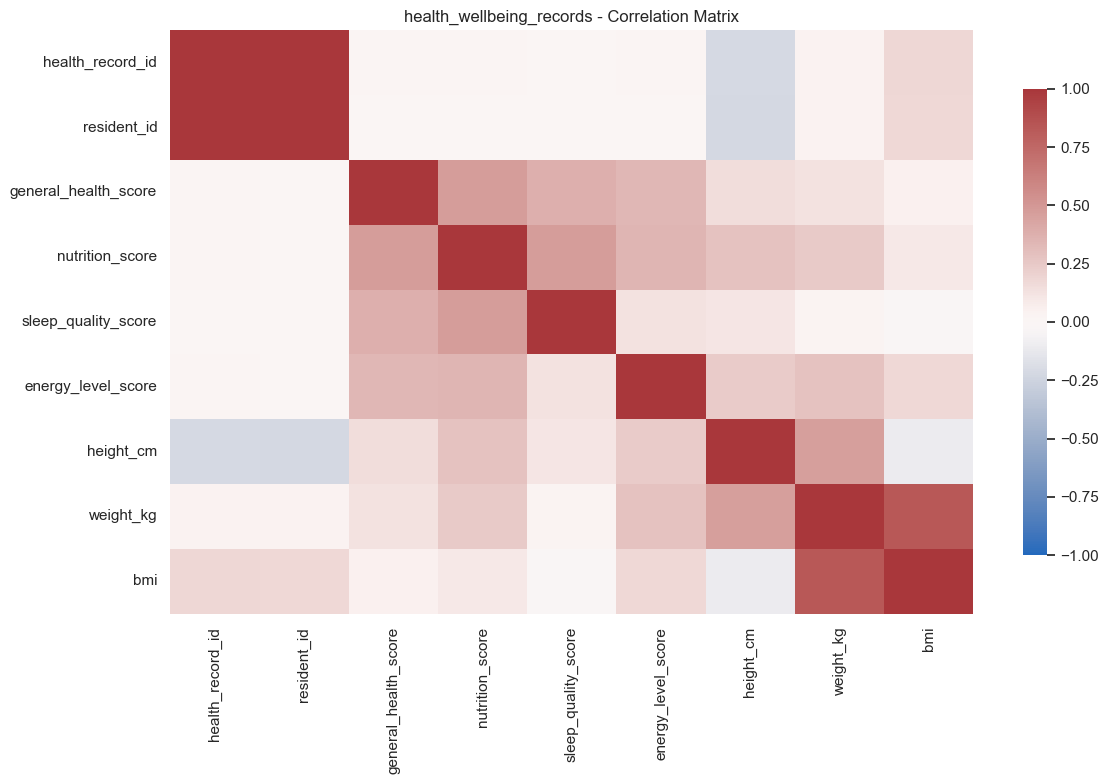

Top absolute correlations:


,feature_1,feature_2,correlation
0,health_record_id,resident_id,0.999685
8,resident_id,health_record_id,0.999685
63,weight_kg,bmi,0.829991
71,bmi,weight_kg,0.829991
35,sleep_quality_score,nutrition_score,0.471471
27,nutrition_score,sleep_quality_score,0.471471
26,nutrition_score,general_health_score,0.470597
18,general_health_score,nutrition_score,0.470597
54,height_cm,weight_kg,0.467202
62,weight_kg,height_cm,0.467202


Correlation analysis for: home_visitations


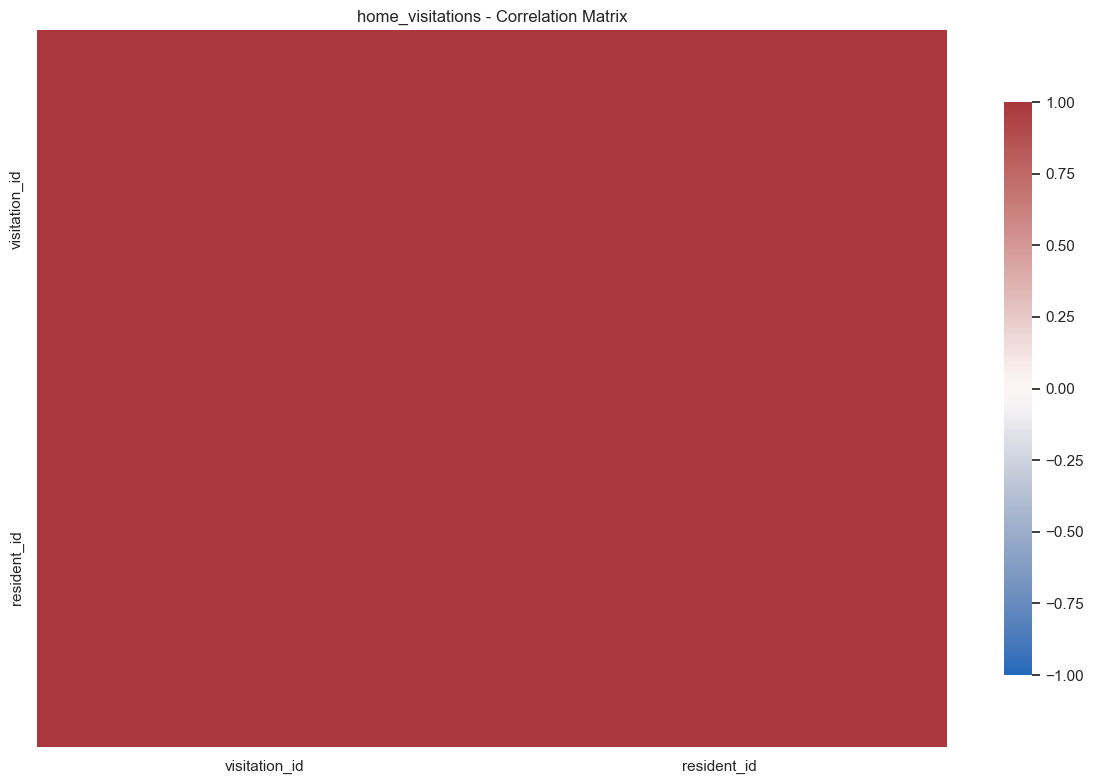

Top absolute correlations:


,feature_1,feature_2,correlation
0,visitation_id,resident_id,0.994959
1,resident_id,visitation_id,0.994959


Correlation analysis for: intervention_plans


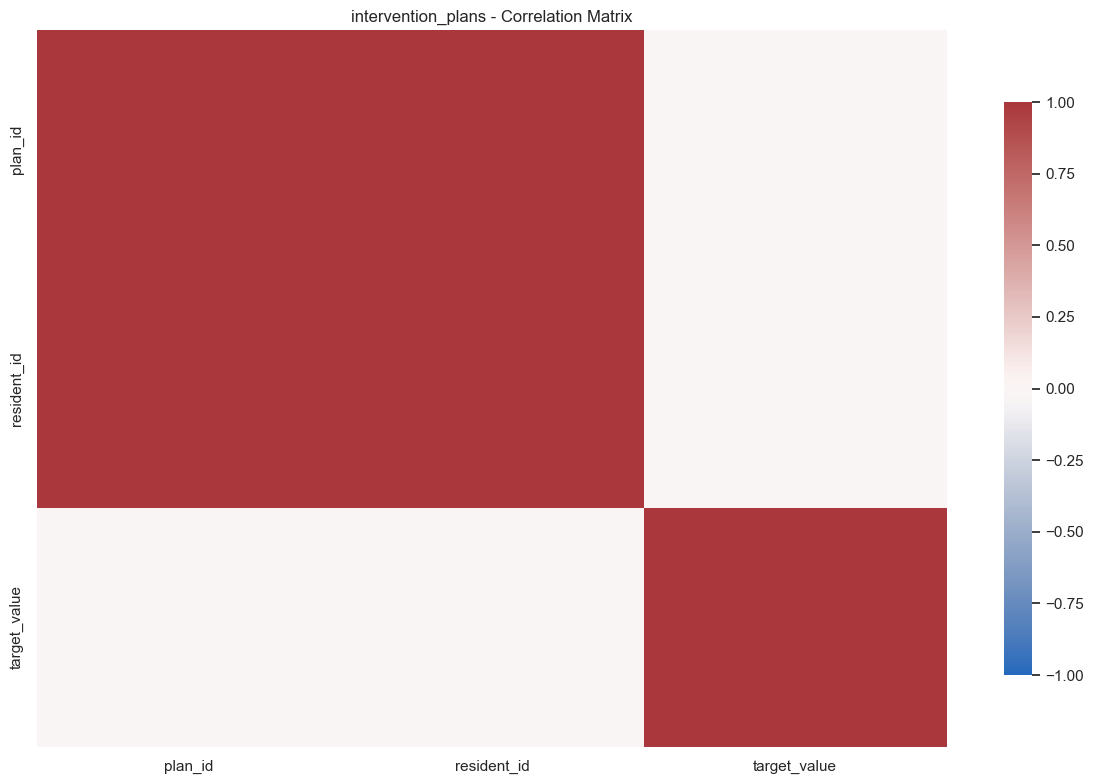

Top absolute correlations:


,feature_1,feature_2,correlation
0,plan_id,resident_id,0.999877
2,resident_id,plan_id,0.999877
3,resident_id,target_value,-0.006841
5,target_value,resident_id,-0.006841
1,plan_id,target_value,-0.006841
4,target_value,plan_id,-0.006841


Correlation analysis for: incident_reports


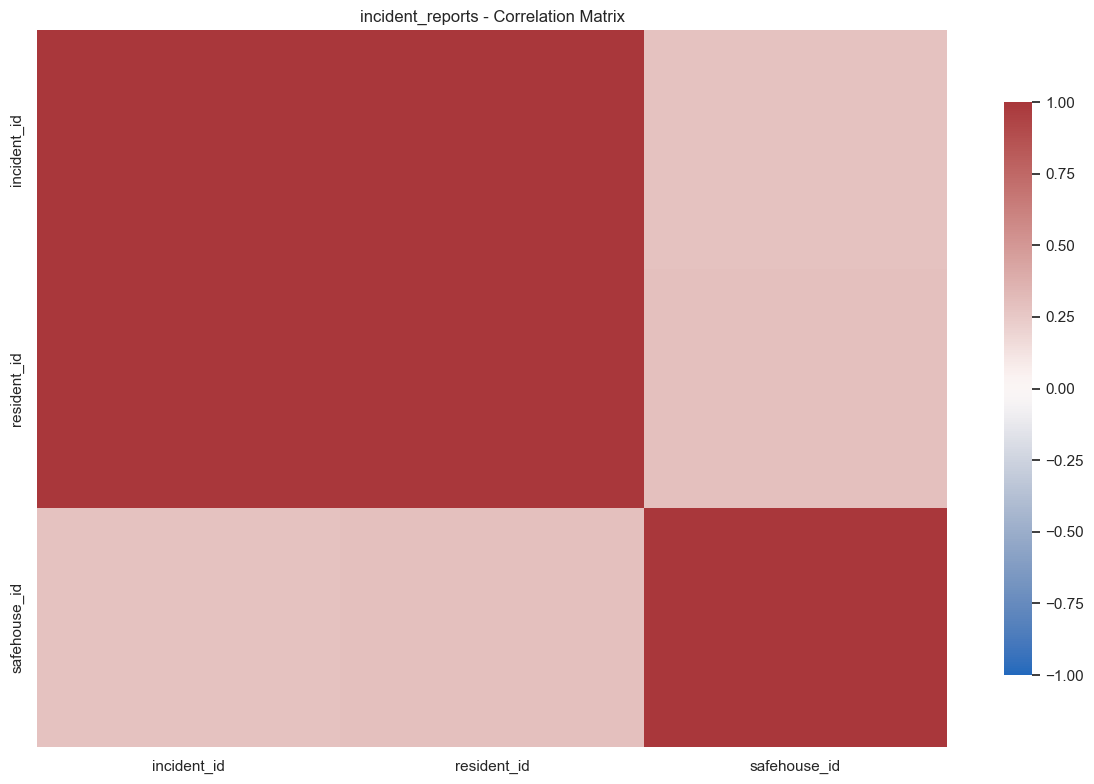

Top absolute correlations:


,feature_1,feature_2,correlation
0,incident_id,resident_id,0.998277
2,resident_id,incident_id,0.998277
3,resident_id,safehouse_id,0.291984
5,safehouse_id,resident_id,0.291984
1,incident_id,safehouse_id,0.286603
4,safehouse_id,incident_id,0.286603


In [31]:
# Additional Correlation Cell: One correlation matrix per dataset
# Assumes `dataframes` is already created in Chapter 1.
for name, df in dataframes.items():
    numeric_df = df.select_dtypes(include=np.number)

    print("=" * 90)
    print(f"Correlation analysis for: {name}")

    if numeric_df.shape[1] < 2:
        print("Skipped: not enough numeric columns for correlation.")
        continue

    corr = numeric_df.corr(numeric_only=True)

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        corr,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=False,
        cbar_kws={"shrink": 0.8},
    )
    plt.title(f"{name} - Correlation Matrix")
    plt.tight_layout()
    plt.show()

    # Optional: print strongest absolute correlations (excluding self-correlation)
    corr_pairs = (
        corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .rename("correlation")
        .reset_index()
    )
    corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
    corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
    top_pairs = corr_pairs.sort_values("abs_corr", ascending=False).head(10)

    print("Top absolute correlations:")
    display(top_pairs[["feature_1", "feature_2", "correlation"]])

In [32]:
# Question Analysis Setup (helper utilities)
# Run this once after Chapter 1 so all question cells can reuse it.

import pandas as pd
import numpy as np


def _first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _pick_join_key(df_left, df_right):
    key_candidates = [
        "resident_id", "client_id", "participant_id", "person_id", "individual_id", "case_id", "id"
    ]
    for k in key_candidates:
        if k in df_left.columns and k in df_right.columns:
            return k
    # fallback: first shared column that looks like an id
    shared = [c for c in df_left.columns if c in df_right.columns and "id" in c.lower()]
    return shared[0] if shared else None


def _safe_corr(df, x, y):
    if x not in df.columns or y not in df.columns:
        return np.nan
    s = df[[x, y]].dropna()
    if len(s) < 3:
        return np.nan
    return s[x].corr(s[y])


def _interpret_corr(val):
    if pd.isna(val):
        return "insufficient data to estimate correlation"
    a = abs(val)
    if a >= 0.7:
        strength = "strong"
    elif a >= 0.4:
        strength = "moderate"
    elif a >= 0.2:
        strength = "weak"
    else:
        strength = "very weak / near-zero"
    direction = "positive" if val > 0 else "negative"
    if a < 0.2:
        return f"{strength} relationship (r={val:.3f})"
    return f"{strength} {direction} relationship (r={val:.3f})"

print("Helpers loaded. Run the question cells below.")

Helpers loaded. Run the question cells below.


In [33]:
# Question 1: Health vs. Education
# Does higher general_health_score correlate with attendance_rate or progress_percent?

health_df = dataframes.get("health_wellbeing_records")
edu_df = dataframes.get("education_records")

if health_df is None or edu_df is None:
    print("Missing required datasets: health_wellbeing_records and/or education_records")
else:
    join_key = _pick_join_key(health_df, edu_df)
    health_col = _first_existing(health_df, ["general_health_score", "health_score"])
    attendance_col = _first_existing(edu_df, ["attendance_rate", "attendance_rates"])
    progress_col = _first_existing(edu_df, ["progress_percent", "progress_percentage", "completion_percent"])

    if not join_key:
        print("No shared ID key found between health and education datasets.")
    elif not health_col:
        print("No health score column found (expected general_health_score/health_score).")
    else:
        merged = health_df[[join_key, health_col]].merge(
            edu_df[[c for c in [join_key, attendance_col, progress_col] if c is not None]],
            on=join_key,
            how="inner",
        )

        corr_att = _safe_corr(merged, health_col, attendance_col) if attendance_col else np.nan
        corr_prog = _safe_corr(merged, health_col, progress_col) if progress_col else np.nan

        print(f"Join key used: {join_key}")
        print(f"Rows available for analysis: {len(merged)}")
        if attendance_col:
            print(f"general_health_score vs {attendance_col}: {_interpret_corr(corr_att)}")
        else:
            print("Attendance column not found.")
        if progress_col:
            print(f"general_health_score vs {progress_col}: {_interpret_corr(corr_prog)}")
        else:
            print("Progress column not found.")

        print("\nAnswer:")
        if pd.isna(corr_att) and pd.isna(corr_prog):
            print("Not enough aligned data to conclude whether better health tracks with education outcomes.")
        else:
            details = []
            if not pd.isna(corr_att):
                details.append(f"attendance correlation is {_interpret_corr(corr_att)}")
            if not pd.isna(corr_prog):
                details.append(f"progress correlation is {_interpret_corr(corr_prog)}")
            print("Higher general health appears related to education outcomes as follows: " + "; ".join(details) + ".")

Join key used: resident_id
Rows available for analysis: 4988
general_health_score vs attendance_rate: very weak / near-zero relationship (r=0.047)
general_health_score vs progress_percent: very weak / near-zero relationship (r=0.152)

Answer:
Higher general health appears related to education outcomes as follows: attendance correlation is very weak / near-zero relationship (r=0.047); progress correlation is very weak / near-zero relationship (r=0.152).


In [34]:
# Question 2: Incidents vs. Outcomes
# Do frequent/high-severity incidents link to follow_up_needed or slower intervention progress?

inc_df = dataframes.get("incident_reports")
home_df = dataframes.get("home_visitations")
plan_df = dataframes.get("intervention_plans")

if inc_df is None:
    print("Missing incident_reports dataset.")
else:
    inc_key = _first_existing(inc_df, ["resident_id", "client_id", "participant_id", "person_id", "individual_id", "case_id", "id"])
    sev_col = _first_existing(inc_df, ["severity", "incident_severity", "severity_level", "risk_level"])

    if not inc_key:
        print("No incident ID key found for grouping incidents.")
    else:
        inc_work = inc_df.copy()
        if sev_col:
            sev_num = pd.to_numeric(inc_work[sev_col], errors="coerce")
            if sev_num.notna().sum() == 0:
                sev_map = {"low": 1, "medium": 2, "high": 3, "critical": 4}
                sev_num = inc_work[sev_col].astype(str).str.lower().map(sev_map)
            inc_work["severity_num"] = sev_num
        else:
            inc_work["severity_num"] = np.nan

        inc_summary = (
            inc_work.groupby(inc_key, dropna=False)
            .agg(
                incident_count=(inc_key, "size"),
                avg_severity=("severity_num", "mean"),
                max_severity=("severity_num", "max"),
            )
            .reset_index()
        )

        print(f"Incident grouping key: {inc_key}")
        print(f"Grouped entities: {len(inc_summary)}")

        # Part A: incidents vs follow_up_needed (home visits)
        if home_df is not None:
            home_key = _pick_join_key(inc_summary, home_df)
            follow_col = _first_existing(home_df, ["follow_up_needed", "needs_follow_up", "followup_needed"])

            if home_key and follow_col:
                h = home_df[[home_key, follow_col]].copy()
                if h[follow_col].dtype == bool:
                    h["follow_up_flag"] = h[follow_col].astype(int)
                else:
                    h["follow_up_flag"] = (
                        h[follow_col].astype(str).str.lower().isin(["1", "true", "yes", "y", "needed"])
                    ).astype(int)

                home_summary = h.groupby(home_key, dropna=False)["follow_up_flag"].mean().reset_index()
                merged_home = inc_summary.merge(home_summary, left_on=inc_key, right_on=home_key, how="inner")

                r_count_follow = _safe_corr(merged_home, "incident_count", "follow_up_flag")
                r_sev_follow = _safe_corr(merged_home, "avg_severity", "follow_up_flag")

                print("\nIncidents -> Home Visit Follow-up")
                print(f"incident_count vs follow_up_needed: {_interpret_corr(r_count_follow)}")
                print(f"avg_severity vs follow_up_needed: {_interpret_corr(r_sev_follow)}")
            else:
                print("\nCould not evaluate follow-up link (missing shared key or follow-up column).")
        else:
            print("\nHome visitation dataset missing; skipped follow-up analysis.")

        # Part B: incidents vs intervention progress
        if plan_df is not None:
            plan_key = _pick_join_key(inc_summary, plan_df)
            prog_col = _first_existing(plan_df, ["progress_percent", "progress_percentage", "completion_percent"])

            if plan_key and prog_col:
                p = plan_df[[plan_key, prog_col]].copy()
                plan_summary = p.groupby(plan_key, dropna=False)[prog_col].mean().reset_index()
                merged_plan = inc_summary.merge(plan_summary, left_on=inc_key, right_on=plan_key, how="inner")

                r_count_prog = _safe_corr(merged_plan, "incident_count", prog_col)
                r_sev_prog = _safe_corr(merged_plan, "avg_severity", prog_col)

                print("\nIncidents -> Intervention Progress")
                print(f"incident_count vs {prog_col}: {_interpret_corr(r_count_prog)}")
                print(f"avg_severity vs {prog_col}: {_interpret_corr(r_sev_prog)}")

                print("\nAnswer:")
                msg = []
                if not pd.isna(r_count_follow := locals().get("r_count_follow", np.nan)):
                    msg.append(f"incident frequency to follow-up is {_interpret_corr(r_count_follow)}")
                if not pd.isna(r_count_prog):
                    msg.append(f"incident frequency to intervention progress is {_interpret_corr(r_count_prog)}")
                if not pd.isna(r_sev_prog):
                    msg.append(f"incident severity to intervention progress is {_interpret_corr(r_sev_prog)}")
                if msg:
                    print("Frequent/high-severity incidents relate to outcomes as follows: " + "; ".join(msg) + ".")
                else:
                    print("Insufficient aligned columns/records to conclude this question.")
            else:
                print("\nCould not evaluate intervention progress link (missing shared key or progress column).")
        else:
            print("\nIntervention plans dataset missing; skipped progress analysis.")

Incident grouping key: resident_id
Grouped entities: 44

Incidents -> Home Visit Follow-up
incident_count vs follow_up_needed: very weak / near-zero relationship (r=0.098)
avg_severity vs follow_up_needed: very weak / near-zero relationship (r=0.142)

Could not evaluate intervention progress link (missing shared key or progress column).


In [35]:
# Question 3: Intervention Efficacy
# How do services_provided in intervention plans impact visit outcomes or health scores?

plan_df = dataframes.get("intervention_plans")
home_df = dataframes.get("home_visitations")
health_df = dataframes.get("health_wellbeing_records")

if plan_df is None:
    print("Missing intervention_plans dataset.")
else:
    services_col = _first_existing(plan_df, ["services_provided", "service_type", "services", "intervention_type"])
    plan_key_for_home = _pick_join_key(plan_df, home_df) if home_df is not None else None
    plan_key_for_health = _pick_join_key(plan_df, health_df) if health_df is not None else None

    if not services_col:
        print("No services column found (expected services_provided/service_type/services/intervention_type).")
    else:
        # Normalize service labels
        plan_work = plan_df.copy()
        plan_work[services_col] = plan_work[services_col].astype(str).str.strip().replace("", np.nan)

        # A) Services vs visit outcomes
        evaluated_any = False
        if home_df is not None and plan_key_for_home:
            visit_outcome_col = _first_existing(home_df, ["visit_outcome", "outcome", "visit_status"])
            follow_col = _first_existing(home_df, ["follow_up_needed", "needs_follow_up", "followup_needed"])

            cols = [plan_key_for_home, services_col]
            left = plan_work[cols].dropna(subset=[services_col])

            right_cols = [c for c in [plan_key_for_home, visit_outcome_col, follow_col] if c is not None]
            right = home_df[right_cols].copy()

            merged = left.merge(right, on=plan_key_for_home, how="inner")
            if len(merged) > 0:
                evaluated_any = True
                print("Services -> Home Visit Outcomes")
                if visit_outcome_col:
                    display(
                        merged.groupby(services_col, dropna=False)[visit_outcome_col]
                        .value_counts(normalize=True)
                        .rename("share")
                        .reset_index()
                        .sort_values([services_col, "share"], ascending=[True, False])
                        .groupby(services_col)
                        .head(3)
                    )
                if follow_col:
                    follow_tmp = merged[[services_col, follow_col]].copy()
                    if follow_tmp[follow_col].dtype == bool:
                        follow_tmp["follow_up_flag"] = follow_tmp[follow_col].astype(int)
                    else:
                        follow_tmp["follow_up_flag"] = (
                            follow_tmp[follow_col].astype(str).str.lower().isin(["1", "true", "yes", "y", "needed"])
                        ).astype(int)
                    display(
                        follow_tmp.groupby(services_col, dropna=False)["follow_up_flag"]
                        .mean()
                        .sort_values(ascending=False)
                        .rename("follow_up_rate")
                        .to_frame()
                        .head(15)
                    )

        # B) Services vs health scores
        if health_df is not None and plan_key_for_health:
            health_col = _first_existing(health_df, ["general_health_score", "health_score"])
            if health_col:
                left = plan_work[[plan_key_for_health, services_col]].dropna(subset=[services_col])
                right = health_df[[plan_key_for_health, health_col]].copy()
                merged_h = left.merge(right, on=plan_key_for_health, how="inner")

                if len(merged_h) > 0:
                    evaluated_any = True
                    print("\nServices -> Health Scores")
                    display(
                        merged_h.groupby(services_col, dropna=False)[health_col]
                        .agg(["count", "mean", "median", "std"])
                        .sort_values("mean", ascending=False)
                        .head(20)
                    )

        print("\nAnswer:")
        if evaluated_any:
            print(
                "Services appear to have differentiated outcomes when comparing outcome distributions/follow-up rates and average health scores by service type. "
                "Use the top tables above to identify which specific services align with stronger outcomes in your data."
            )
        else:
            print("Could not estimate intervention efficacy due to missing shared keys or required columns.")

Services -> Home Visit Outcomes


,services_provided,visit_outcome,share
0,Caring,Favorable,0.366071
1,Caring,Needs Improvement,0.290179
2,Caring,Inconclusive,0.200893
4,"Caring, Healing",Favorable,0.426230
5,"Caring, Healing",Needs Improvement,0.289617
...,...,...,...
153,"Teaching, Legal Services, Caring",Needs Improvement,0.301587
154,"Teaching, Legal Services, Caring",Inconclusive,0.222222
156,"Teaching, Legal Services, Healing",Needs Improvement,0.428571
157,"Teaching, Legal Services, Healing",Favorable,0.392857


,follow_up_rate
services_provided,
"Caring, Legal Services, Healing",0.505618
"Teaching, Healing, Caring",0.505376
"Teaching, Legal Services, Healing",0.500000
"Healing, Teaching, Caring",0.478261
"Healing, Caring",0.476510
"Legal Services, Caring",0.464286
"Caring, Teaching, Healing",0.462963
"Legal Services, Teaching",0.454545
"Caring, Healing, Legal Services",0.437500



Services -> Health Scores


,count,mean,median,std
services_provided,,,,
"Legal Services, Teaching, Healing",12,3.502500,3.500,0.279484
"Healing, Caring, Legal Services",28,3.455000,3.320,0.378491
"Teaching, Healing",49,3.369184,3.300,0.282001
Teaching,154,3.347468,3.250,0.306416
"Caring, Legal Services, Teaching",36,3.306667,3.270,0.276064
"Legal Services, Caring, Healing",13,3.292308,3.270,0.156053
"Teaching, Legal Services",38,3.279211,3.285,0.154542
"Teaching, Caring",48,3.262917,3.160,0.329648
"Teaching, Caring, Healing",34,3.261471,3.180,0.224150



Answer:
Services appear to have differentiated outcomes when comparing outcome distributions/follow-up rates and average health scores by service type. Use the top tables above to identify which specific services align with stronger outcomes in your data.


In [36]:
# Problem 1: Early-risk identification (proxy)
# Question: Which individuals look high-risk for needing urgent follow-up?

home_df = dataframes.get("home_visitations")
inc_df = dataframes.get("incident_reports")
health_df = dataframes.get("health_wellbeing_records")

if home_df is None:
    print("Missing home_visitations dataset.")
else:
    id_col = _first_existing(home_df, ["resident_id", "client_id", "participant_id", "person_id", "individual_id", "case_id", "id"])
    follow_col = _first_existing(home_df, ["follow_up_needed", "needs_follow_up", "followup_needed"])

    if not id_col:
        print("No ID column found in home_visitations.")
    else:
        base = home_df[[id_col]].drop_duplicates().copy()

        # Incident features
        if inc_df is not None:
            inc_id = _pick_join_key(base, inc_df)
            sev_col = _first_existing(inc_df, ["severity", "incident_severity", "severity_level", "risk_level"])
            if inc_id:
                tmp = inc_df.copy()
                if sev_col:
                    sev_num = pd.to_numeric(tmp[sev_col], errors="coerce")
                    if sev_num.notna().sum() == 0:
                        sev_num = tmp[sev_col].astype(str).str.lower().map({"low": 1, "medium": 2, "high": 3, "critical": 4})
                    tmp["sev_num"] = sev_num
                else:
                    tmp["sev_num"] = np.nan

                inc_features = tmp.groupby(inc_id, dropna=False).agg(
                    incident_count=(inc_id, "size"),
                    avg_severity=("sev_num", "mean"),
                ).reset_index().rename(columns={inc_id: id_col})
                base = base.merge(inc_features, on=id_col, how="left")

        # Health feature
        if health_df is not None:
            h_id = _pick_join_key(base, health_df)
            h_col = _first_existing(health_df, ["general_health_score", "health_score"])
            if h_id and h_col:
                h = health_df.groupby(h_id, dropna=False)[h_col].mean().reset_index().rename(columns={h_id: id_col, h_col: "health_score"})
                base = base.merge(h, on=id_col, how="left")

        # Home follow-up signal
        if follow_col:
            h = home_df[[id_col, follow_col]].copy()
            if h[follow_col].dtype == bool:
                h["follow_flag"] = h[follow_col].astype(int)
            else:
                h["follow_flag"] = h[follow_col].astype(str).str.lower().isin(["1", "true", "yes", "y", "needed"]).astype(int)
            f = h.groupby(id_col, dropna=False)["follow_flag"].mean().reset_index()
            base = base.merge(f, on=id_col, how="left")

        # Risk score (heuristic, percentile-based)
        for c in ["incident_count", "avg_severity"]:
            if c not in base.columns:
                base[c] = np.nan
        if "health_score" not in base.columns:
            base["health_score"] = np.nan

        base["incident_rank"] = base["incident_count"].rank(pct=True)
        base["severity_rank"] = base["avg_severity"].rank(pct=True)
        base["low_health_rank"] = (1 - base["health_score"].rank(pct=True))
        base["risk_score"] = (0.5 * base["incident_rank"].fillna(0)
                              + 0.3 * base["severity_rank"].fillna(0)
                              + 0.2 * base["low_health_rank"].fillna(0))

        top_risk = base.sort_values("risk_score", ascending=False).head(15)
        display(top_risk[[c for c in [id_col, "risk_score", "incident_count", "avg_severity", "health_score", "follow_flag"] if c in top_risk.columns]])

        print("Answer:")
        if "follow_flag" in base.columns:
            corr = _safe_corr(base, "risk_score", "follow_flag")
            print(f"Higher composite risk scores show {_interpret_corr(corr)} with observed follow-up need.")
        else:
            print("High-risk individuals are those with high incident frequency/severity and lower health scores (see ranked table).")

,resident_id,risk_score,incident_count,avg_severity,health_score,follow_flag
13,14,0.938532,4.0,3.000000,2.908750,0.428571
49,52,0.819046,3.0,2.666667,3.025714,0.416667
39,41,0.774459,5.0,1.600000,2.552500,0.307692
16,17,0.748396,5.0,2.200000,3.332222,0.333333
11,12,0.748075,4.0,2.250000,3.250833,0.466667
44,46,0.737570,3.0,2.333333,3.146250,0.470588
0,1,0.715798,4.0,1.750000,3.103333,0.500000
7,8,0.711708,3.0,2.333333,3.175000,0.352941
55,58,0.683039,4.0,1.750000,3.157778,0.352941
42,44,0.668685,3.0,1.666667,2.693333,0.352941


Answer:
Higher composite risk scores show very weak / near-zero relationship (r=-0.100) with observed follow-up need.


In [37]:
# Problem 2: Attendance/progress decline prevention
# Question: Who is at risk of low attendance or stalled progress?

edu_df = dataframes.get("education_records")
health_df = dataframes.get("health_wellbeing_records")

if edu_df is None:
    print("Missing education_records dataset.")
else:
    id_col = _first_existing(edu_df, ["resident_id", "client_id", "participant_id", "person_id", "individual_id", "case_id", "id"])
    attend_col = _first_existing(edu_df, ["attendance_rate", "attendance_rates"])
    prog_col = _first_existing(edu_df, ["progress_percent", "progress_percentage", "completion_percent"])

    if not id_col or (not attend_col and not prog_col):
        print("Required columns missing (ID + attendance/progress).")
    else:
        risk = edu_df[[c for c in [id_col, attend_col, prog_col] if c is not None]].copy()

        if health_df is not None:
            h_id = _pick_join_key(risk, health_df)
            h_col = _first_existing(health_df, ["general_health_score", "health_score"])
            if h_id and h_col:
                h = health_df.groupby(h_id, dropna=False)[h_col].mean().reset_index()
                h = h.rename(columns={h_id: id_col, h_col: "health_score"})
                risk = risk.merge(h, on=id_col, how="left")

        if attend_col:
            risk["low_attendance_flag"] = (risk[attend_col] < risk[attend_col].median()).astype(int)
        if prog_col:
            risk["low_progress_flag"] = (risk[prog_col] < risk[prog_col].median()).astype(int)

        if attend_col and prog_col:
            risk["decline_score"] = (1 - risk[attend_col].rank(pct=True)) * 0.5 + (1 - risk[prog_col].rank(pct=True)) * 0.5
        elif attend_col:
            risk["decline_score"] = (1 - risk[attend_col].rank(pct=True))
        else:
            risk["decline_score"] = (1 - risk[prog_col].rank(pct=True))

        display(risk.sort_values("decline_score", ascending=False).head(15))

        print("Answer:")
        if "health_score" in risk.columns and attend_col:
            print(f"Health vs attendance: {_interpret_corr(_safe_corr(risk, 'health_score', attend_col))}")
        if "health_score" in risk.columns and prog_col:
            print(f"Health vs progress: {_interpret_corr(_safe_corr(risk, 'health_score', prog_col))}")
        print("Individuals at the top of decline_score are highest priority for attendance/progress intervention.")

,resident_id,attendance_rate,progress_percent,health_score,low_attendance_flag,low_progress_flag,decline_score
76,9,0.398,4.6,3.157778,1,1,0.993446
100,12,0.393,6.9,3.250833,1,1,0.993446
99,12,0.384,11.4,3.250833,1,1,0.993446
75,9,0.449,0.0,3.157778,1,1,0.992509
286,33,0.442,25.0,3.038750,1,1,0.985955
457,52,0.488,20.9,3.025714,1,1,0.980337
74,9,0.505,4.0,3.157778,1,1,0.979401
437,50,0.468,33.9,3.604167,1,1,0.970974
102,12,0.505,29.7,3.250833,1,1,0.966292
455,52,0.505,33.2,3.025714,1,1,0.964419


Answer:
Health vs attendance: very weak / near-zero relationship (r=0.053)
Health vs progress: very weak / near-zero relationship (r=0.193)
Individuals at the top of decline_score are highest priority for attendance/progress intervention.


In [38]:
# Problem 3: Incident escalation prevention
# Question: Which cases are likely to escalate to severe incidents?

inc_df = dataframes.get("incident_reports")
if inc_df is None:
    print("Missing incident_reports dataset.")
else:
    id_col = _first_existing(inc_df, ["resident_id", "client_id", "participant_id", "person_id", "individual_id", "case_id", "id"])
    sev_col = _first_existing(inc_df, ["severity", "incident_severity", "severity_level", "risk_level"])

    if not id_col or not sev_col:
        print("Need both ID and severity column in incident_reports.")
    else:
        tmp = inc_df[[id_col, sev_col]].copy()
        tmp["sev_num"] = pd.to_numeric(tmp[sev_col], errors="coerce")
        if tmp["sev_num"].notna().sum() == 0:
            tmp["sev_num"] = tmp[sev_col].astype(str).str.lower().map({"low": 1, "medium": 2, "high": 3, "critical": 4})

        # Escalation proxy: max severity >= 3 (high/critical)
        summary = tmp.groupby(id_col, dropna=False).agg(
            incident_count=(id_col, "size"),
            avg_severity=("sev_num", "mean"),
            max_severity=("sev_num", "max"),
        ).reset_index()
        summary["escalation_flag"] = (summary["max_severity"] >= 3).astype(int)

        display(summary.sort_values(["escalation_flag", "incident_count", "avg_severity"], ascending=[False, False, False]).head(20))

        print("Answer:")
        print(f"Incident_count vs escalation_flag: {_interpret_corr(_safe_corr(summary, 'incident_count', 'escalation_flag'))}")
        print(f"Avg_severity vs escalation_flag: {_interpret_corr(_safe_corr(summary, 'avg_severity', 'escalation_flag'))}")
        print("Cases with high incident_count and high avg_severity should be prioritized for escalation prevention.")

,resident_id,incident_count,avg_severity,max_severity,escalation_flag
12,17,5,2.200000,3,1
10,14,4,3.000000,3,1
9,12,4,2.250000,3,1
0,1,4,1.750000,3,1
37,52,3,2.666667,3,1
6,8,3,2.333333,3,1
17,23,3,2.333333,3,1
28,36,3,2.333333,3,1
34,46,3,2.333333,3,1
20,26,3,2.000000,3,1


Answer:
Incident_count vs escalation_flag: weak positive relationship (r=0.398)
Avg_severity vs escalation_flag: moderate positive relationship (r=0.675)
Cases with high incident_count and high avg_severity should be prioritized for escalation prevention.


In [39]:
# Problem 4: Intervention effectiveness optimization
# Question: Which services are associated with better outcomes?

plan_df = dataframes.get("intervention_plans")
home_df = dataframes.get("home_visitations")
health_df = dataframes.get("health_wellbeing_records")

if plan_df is None:
    print("Missing intervention_plans dataset.")
else:
    svc_col = _first_existing(plan_df, ["services_provided", "service_type", "services", "intervention_type"])
    if not svc_col:
        print("No services column found in intervention_plans.")
    else:
        print("Service effectiveness views:")

        # Services vs follow-up rate (lower is better)
        if home_df is not None:
            k = _pick_join_key(plan_df, home_df)
            follow_col = _first_existing(home_df, ["follow_up_needed", "needs_follow_up", "followup_needed"])
            if k and follow_col:
                merged = plan_df[[k, svc_col]].merge(home_df[[k, follow_col]], on=k, how="inner")
                if len(merged):
                    f = merged.copy()
                    f["follow_flag"] = f[follow_col] if f[follow_col].dtype == bool else f[follow_col].astype(str).str.lower().isin(["1", "true", "yes", "y", "needed"])
                    table = f.groupby(svc_col, dropna=False)["follow_flag"].mean().sort_values()
                    display(table.rename("follow_up_rate").to_frame().head(15))

        # Services vs health score (higher may be better)
        if health_df is not None:
            k2 = _pick_join_key(plan_df, health_df)
            h_col = _first_existing(health_df, ["general_health_score", "health_score"])
            if k2 and h_col:
                merged_h = plan_df[[k2, svc_col]].merge(health_df[[k2, h_col]], on=k2, how="inner")
                if len(merged_h):
                    table_h = merged_h.groupby(svc_col, dropna=False)[h_col].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
                    display(table_h.head(15))

        print("Answer:")
        print("Service categories with lower follow-up rates and/or higher mean health scores are your strongest candidates for scaling.")

Service effectiveness views:


,follow_up_rate
services_provided,
"Teaching, Legal Services",0.159091
"Healing, Caring, Teaching",0.272727
"Healing, Caring, Legal Services",0.312500
"Legal Services, Teaching, Healing",0.315789
"Healing, Legal Services",0.315789
"Teaching, Healing",0.336735
"Legal Services, Healing, Caring",0.347826
"Teaching, Healing, Legal Services",0.352941
"Caring, Healing, Teaching",0.359375


,count,mean,median
services_provided,,,
"Legal Services, Teaching, Healing",12,3.502500,3.500
"Healing, Caring, Legal Services",28,3.455000,3.320
"Teaching, Healing",49,3.369184,3.300
Teaching,154,3.347468,3.250
"Caring, Legal Services, Teaching",36,3.306667,3.270
"Legal Services, Caring, Healing",13,3.292308,3.270
"Teaching, Legal Services",38,3.279211,3.285
"Teaching, Caring",48,3.262917,3.160
"Teaching, Caring, Healing",34,3.261471,3.180


Answer:
Service categories with lower follow-up rates and/or higher mean health scores are your strongest candidates for scaling.


In [40]:
# Problem 5: Care plan prioritization
# Question: Which cases should be prioritized first for intervention resources?

plan_df = dataframes.get("intervention_plans")
inc_df = dataframes.get("incident_reports")
home_df = dataframes.get("home_visitations")

if plan_df is None:
    print("Missing intervention_plans dataset.")
else:
    id_col = _first_existing(plan_df, ["resident_id", "client_id", "participant_id", "person_id", "individual_id", "case_id", "id"])
    prog_col = _first_existing(plan_df, ["progress_percent", "progress_percentage", "completion_percent"])

    if not id_col:
        print("No ID column found in intervention_plans.")
    else:
        pri = plan_df[[id_col] + ([prog_col] if prog_col else [])].drop_duplicates(subset=[id_col]).copy()

        if inc_df is not None:
            k = _pick_join_key(pri, inc_df)
            if k:
                inc_count = inc_df.groupby(k, dropna=False).size().rename("incident_count").reset_index().rename(columns={k: id_col})
                pri = pri.merge(inc_count, on=id_col, how="left")

        if home_df is not None:
            k2 = _pick_join_key(pri, home_df)
            follow_col = _first_existing(home_df, ["follow_up_needed", "needs_follow_up", "followup_needed"])
            if k2 and follow_col:
                h = home_df[[k2, follow_col]].copy()
                h["follow_flag"] = h[follow_col] if h[follow_col].dtype == bool else h[follow_col].astype(str).str.lower().isin(["1", "true", "yes", "y", "needed"])
                follow_rate = h.groupby(k2, dropna=False)["follow_flag"].mean().reset_index().rename(columns={k2: id_col})
                pri = pri.merge(follow_rate, on=id_col, how="left")

        if "incident_count" not in pri.columns:
            pri["incident_count"] = np.nan
        if "follow_flag" not in pri.columns:
            pri["follow_flag"] = np.nan
        if prog_col is None:
            pri["progress_proxy"] = np.nan
            prog_rank = 0
        else:
            pri["progress_proxy"] = pri[prog_col]
            prog_rank = (1 - pri["progress_proxy"].rank(pct=True)).fillna(0)

        pri["priority_score"] = (
            0.4 * pri["incident_count"].rank(pct=True).fillna(0) +
            0.3 * pri["follow_flag"].rank(pct=True).fillna(0) +
            0.3 * prog_rank
        )

        out = pri.sort_values("priority_score", ascending=False)
        display(out.head(20))

        print("Answer:")
        print("Cases with highest priority_score should be handled first (high incidents, high follow-up need, and slower plan progress).")

,resident_id,incident_count,follow_flag,progress_proxy,priority_score
0,1,4.0,0.500000,NaN,0.611285
22,23,3.0,0.521739,NaN,0.578683
11,12,4.0,0.466667,NaN,0.575078
13,14,4.0,0.428571,NaN,0.556975
45,46,3.0,0.470588,NaN,0.516614
25,26,3.0,0.461538,NaN,0.503683
16,17,5.0,0.333333,NaN,0.483386
51,52,3.0,0.416667,NaN,0.480408
57,58,4.0,0.352941,NaN,0.479389
29,30,2.0,0.607143,NaN,0.476019


Answer:
Cases with highest priority_score should be handled first (high incidents, high follow-up need, and slower plan progress).


In [41]:
# Problem 6: Follow-up burden forecasting (baseline)
# Question: How much follow-up load should we expect over time?

home_df = dataframes.get("home_visitations")
if home_df is None:
    print("Missing home_visitations dataset.")
else:
    date_col = _first_existing(home_df, ["visit_date", "date", "created_at", "timestamp"])
    follow_col = _first_existing(home_df, ["follow_up_needed", "needs_follow_up", "followup_needed"])

    if not date_col or not follow_col:
        print("Need date + follow_up_needed columns for burden forecast.")
    else:
        t = home_df[[date_col, follow_col]].copy()
        t[date_col] = pd.to_datetime(t[date_col], errors="coerce")
        t = t.dropna(subset=[date_col])
        t["follow_flag"] = t[follow_col] if t[follow_col].dtype == bool else t[follow_col].astype(str).str.lower().isin(["1", "true", "yes", "y", "needed"])

        weekly = t.set_index(date_col)["follow_flag"].resample("W").sum().to_frame("follow_ups")
        weekly["baseline_forecast_next_4w"] = weekly["follow_ups"].rolling(8, min_periods=3).mean()

        display(weekly.tail(20))

        next4 = weekly["follow_ups"].tail(8).mean()
        print("Answer:")
        if pd.isna(next4):
            print("Not enough dated data for a baseline forecast.")
        else:
            print(f"Baseline expectation is about {next4:.1f} follow-ups per week over the next month (simple rolling-average benchmark).")

,follow_ups,baseline_forecast_next_4w
visit_date,,
2026-09-13,0,0.625
2026-09-20,0,0.625
2026-09-27,0,0.625
2026-10-04,1,0.750
2026-10-11,0,0.625
2026-10-18,0,0.500
2026-10-25,0,0.125
2026-11-01,0,0.125
2026-11-08,0,0.125


Answer:
Baseline expectation is about 0.1 follow-ups per week over the next month (simple rolling-average benchmark).


In [42]:
# Problem 7: Cross-domain outcome gap detection
# Question: Where do health and education outcomes diverge?

edu_df = dataframes.get("education_records")
health_df = dataframes.get("health_wellbeing_records")

if edu_df is None or health_df is None:
    print("Need education_records and health_wellbeing_records datasets.")
else:
    k = _pick_join_key(edu_df, health_df)
    health_col = _first_existing(health_df, ["general_health_score", "health_score"])
    prog_col = _first_existing(edu_df, ["progress_percent", "progress_percentage", "completion_percent"])

    if not k or not health_col or not prog_col:
        print("Need shared key + health score + progress column.")
    else:
        merged = edu_df[[k, prog_col]].merge(health_df[[k, health_col]], on=k, how="inner").dropna()

        merged["health_rank"] = merged[health_col].rank(pct=True)
        merged["progress_rank"] = merged[prog_col].rank(pct=True)
        merged["gap_score"] = (merged["health_rank"] - merged["progress_rank"]).abs()

        # Positive gap: health > progress; negative gap: progress > health
        merged["gap_direction"] = np.where(
            merged["health_rank"] > merged["progress_rank"],
            "health_ahead_of_progress",
            "progress_ahead_of_health"
        )

        display(merged.sort_values("gap_score", ascending=False).head(20))
        display(merged["gap_direction"].value_counts().to_frame("count"))

        print("Answer:")
        print("Largest gap_score cases are where coordinated support is needed because one domain is advancing while the other lags.")

,resident_id,progress_percent,general_health_score,health_rank,progress_rank,gap_score,gap_direction
4086,50,33.9,3.97,0.989274,0.038392,0.950882,health_ahead_of_progress
4085,50,33.9,3.89,0.978448,0.038392,0.940056,health_ahead_of_progress
4084,50,33.9,3.83,0.967622,0.038392,0.929230,health_ahead_of_progress
4083,50,33.9,3.74,0.959403,0.038392,0.921010,health_ahead_of_progress
4081,50,33.9,3.72,0.952787,0.038392,0.914395,health_ahead_of_progress
3264,39,34.2,3.71,0.948276,0.041500,0.906776,health_ahead_of_progress
4080,50,33.9,3.67,0.940156,0.038392,0.901764,health_ahead_of_progress
4082,50,33.9,3.66,0.936548,0.038392,0.898156,health_ahead_of_progress
3275,39,39.4,3.71,0.948276,0.063553,0.884723,health_ahead_of_progress
1177,15,45.1,3.90,0.982057,0.097835,0.884222,health_ahead_of_progress


,count
gap_direction,
health_ahead_of_progress,2540
progress_ahead_of_health,2448


Answer:
Largest gap_score cases are where coordinated support is needed because one domain is advancing while the other lags.


In [43]:
# Problem 8: Equity/fairness monitoring
# Question: Are outcomes materially different across demographic groups?

home_df = dataframes.get("home_visitations")
if home_df is None:
    print("Missing home_visitations dataset.")
else:
    outcome_col = _first_existing(home_df, ["follow_up_needed", "needs_follow_up", "followup_needed"])
    group_candidates = ["gender", "sex", "race", "ethnicity", "age_group", "region", "location"]
    groups = [g for g in group_candidates if g in home_df.columns]

    if not outcome_col:
        print("No follow-up outcome column found.")
    elif not groups:
        print("No standard demographic grouping columns found for fairness analysis.")
    else:
        w = home_df.copy()
        if w[outcome_col].dtype == bool:
            w["outcome_flag"] = w[outcome_col].astype(int)
        else:
            w["outcome_flag"] = w[outcome_col].astype(str).str.lower().isin(["1", "true", "yes", "y", "needed"]).astype(int)

        print("Group disparity tables:")
        for g in groups:
            tbl = w.groupby(g, dropna=False)["outcome_flag"].agg(["count", "mean"]).sort_values("mean", ascending=False)
            tbl = tbl.rename(columns={"mean": "follow_up_rate"})
            display(tbl)

            if tbl["follow_up_rate"].notna().sum() >= 2:
                gap = tbl["follow_up_rate"].max() - tbl["follow_up_rate"].min()
                print(f"{g} disparity gap (max-min follow_up_rate): {gap:.3f}")

        print("Answer:")
        print("If disparity gaps are large across any group column, that signals potential equity issues and should trigger deeper fairness review and intervention design.")

No standard demographic grouping columns found for fairness analysis.
